In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
import pandas as pd

test_df= pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

In [3]:
train_df.info()

test_df.info()
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 

Train shape: (198000, 15)
Test shape: (102000, 14)

Label distribution:
label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

Missing values:
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64


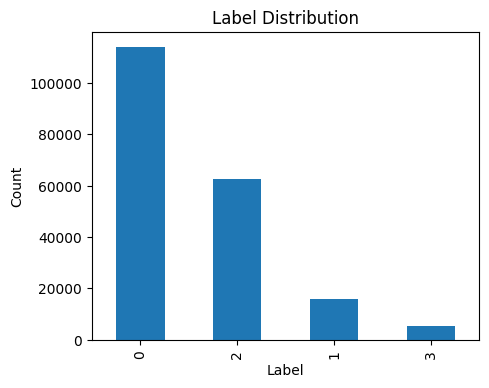

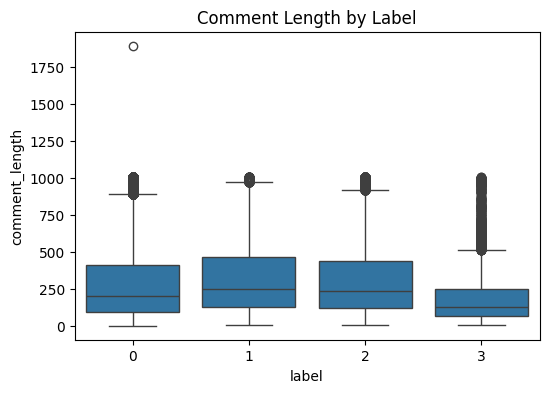


T-test Result:
t-statistic: -17.571943347613804
p-value: 1.2741273311606353e-68

Model Performance:
Accuracy: 0.9020454545454546
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     22835
           1       0.79      0.70      0.74      3183
           2       0.84      0.91      0.87     12488
           3       0.72      0.45      0.55      1094

    accuracy                           0.90     39600
   macro avg       0.83      0.75      0.78     39600
weighted avg       0.90      0.90      0.90     39600



In [4]:
# ===============================
# 1. Imports
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from scipy.sparse import hstack
from scipy.stats import ttest_ind

# ===============================
# 2. Data Loading
# ================================

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# ===============================
# 3. Exploratory Data Analysis
# ===============================
print("\nLabel distribution:")
print(train_df['label'].value_counts())

print("\nMissing values:")
print(train_df.isnull().sum())

# Comment length
train_df['comment'] = train_df['comment'].fillna("")
train_df['comment_length'] = train_df['comment'].apply(len)

# ===============================
# 4. Data Visualization
# ===============================
plt.figure(figsize=(5,4))
train_df['label'].value_counts().plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='label', y='comment_length', data=train_df)
plt.title("Comment Length by Label")
plt.show()

# ===============================
# 5. Statistical Analysis
# ===============================
l0 = train_df[train_df['label'] == 0]['comment_length']
l1 = train_df[train_df['label'] == 1]['comment_length']

t_stat, p_val = ttest_ind(l0, l1, equal_var=False)
print("\nT-test Result:")
print("t-statistic:", t_stat)
print("p-value:", p_val)

# ===============================
# 6. Train–Validation Split
# ===============================
X = train_df.drop(columns=['label'])
y = train_df['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# 7. Data Cleaning & Preprocessing
# ===============================
cat_cols = ['race', 'religion', 'gender']
num_cols = ['emoticon_1','emoticon_2','emoticon_3',
            'upvote','downvote','if_1','if_2']

# Fill missing categorical values
for col in cat_cols:
    X_train[col] = X_train[col].fillna("unknown")
    X_val[col] = X_val[col].fillna("unknown")

# Text vectorization
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_text = tfidf.fit_transform(X_train['comment'])
X_val_text = tfidf.transform(X_val['comment'])

# Scale numerical features
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols])
X_val_num = scaler.transform(X_val[num_cols])

# Combine text + numerical features
X_train_final = hstack([X_train_text, X_train_num])
X_val_final = hstack([X_val_text, X_val_num])

# ===============================
# 8. Baseline Model
# ===============================
model = LogisticRegression(max_iter=1000)
model.fit(X_train_final, y_train)

y_pred = model.predict(X_val_final)

# ===============================
# 9. Evaluation
# ===============================
print("\nModel Performance:")
print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))


In [5]:
# ===============================
# 10. Preprocess Test Data
# ===============================

# Handle missing values
test_df['comment'] = test_df['comment'].fillna("")

for col in ['race', 'religion', 'gender']:
    test_df[col] = test_df[col].fillna("unknown")

# TF-IDF transformation (NO fit here)
X_test_text = tfidf.transform(test_df['comment'])

# Scale numerical features
X_test_num = scaler.transform(test_df[num_cols])

# Combine text + numerical features
X_test_final = hstack([X_test_text, X_test_num])

# ===============================
# 11. Predict Labels
# ===============================
test_predictions = model.predict(X_test_final)

print("Predictions shape:", test_predictions.shape)
print("Unique predicted labels:", np.unique(test_predictions))

# ===============================
# 12. Fill Submission File
# ===============================
submission = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

submission['label'] = test_predictions

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")

Predictions shape: (102000,)
Unique predicted labels: [0 1 2 3]
submission.csv created successfully!


In [6]:
from IPython.display import FileLink
FileLink("submission.csv")

/kaggle/working/submission.csv